# 04_CustomeModel - Tối ưu hóa Learning Rate & Huấn luyện

In [1]:
import sys, os, gc, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import optuna

# Thêm đường dẫn tới thư mục gốc
sys.path.append(os.path.dirname(os.getcwd()))

from utils.config import Config, Params
from utils.data import get_dataloaders
from utils.train import fit
from utils.recipe import build_criterion, build_scheduler, make_param_groups
from utils.evaluate import plot_training_history, evaluate_test_set, plot_misclassified_samples
from models.custome_model import CustomeModelCNN

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)

config = Config()
device = config.DEVICE
print(f"Sử dụng thiết bị: {device}")

STAGE = "custome"
OUT_DIR = f"../output/{STAGE}"
os.makedirs(OUT_DIR, exist_ok=True)

/home/dainguyen1506/Documents/Project/face-anti-spoofing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sử dụng thiết bị: xpu


In [2]:
# Lấy Dataloaders
train_loader, val_loader, test_loader, class_names = get_dataloaders(img_size=config.IMG_SIZE)
print(f"Số lượng classes: {len(class_names)} ({class_names})")

[*] Đang nạp dataset 'train' vào Shared RAM...


[*] Nạp thành công 8299 ảnh (1191.4 MB)
[*] Đang nạp dataset 'val' vào Shared RAM...


[*] Nạp thành công 2948 ảnh (423.2 MB)
[*] Tập test nạp trực tiếp từ ổ cứng (không dùng Cache RAM).
Số lượng classes: 2 (['real', 'spoof'])


In [3]:
# Lấy cấu hình tối ưu từ stage trước
recipe = Params.load_recipe("optimize")
print("Recipe được load:", json.dumps(recipe, indent=2))

EPOCHS_MINI = 6
EPOCHS_FINAL = 30
N_TRIALS = 8
SEED = 42

Recipe được load: {
  "loss_type": "ce",
  "gamma": null,
  "label_smoothing": 0.029122914019804193,
  "weight_decay": 0.00039605150456850803,
  "scheduler": "cosine",
  "selection_metric": "acer_at_eer",
  "sampler": "balanced",
  "lr_hint": 0.0002241521242372111
}


## Mini-sweep: Tìm Learning Rate phù hợp cho Custom Model

In [4]:
def run_training(lr, epochs, experiment_name, seed, trial=None):
    set_seed(seed)
    model = CustomeModelCNN(dropout=0.45, num_classes=len(class_names)).to(device)
    
    # Sử dụng nhóm tham số để không áp dụng weight decay cho bias/batchnorm
    wd = recipe.get("weight_decay", 1e-4)
    param_groups = make_param_groups(model, lr=lr, weight_decay=wd)
    optimizer = optim.AdamW(param_groups)
    
    # Kế thừa hàm loss từ recipe
    criterion = build_criterion(recipe)
    
    # Scheduler
    scheduler = build_scheduler(optimizer, epochs, {"scheduler": "cosine", "warmup_epochs": 1})
    
    model, history = fit(model, train_loader, val_loader, criterion, optimizer, device, class_names,
                         epochs=epochs, config=config, scheduler=scheduler,
                         experiment_name=experiment_name, trial=trial)
    return model, history

def score_of(history):
    return float(np.mean(history['val_acer'][-3:]))

def objective(trial):
    # Khảo sát quanh lr_hint của recipe
    lr_hint = recipe.get("lr_hint", 4e-4)
    lr = trial.suggest_float("lr", lr_hint / 5, lr_hint * 5, log=True)
    
    model, history = run_training(lr, EPOCHS_MINI, f"{STAGE}/trial_{trial.number}", seed=SEED + trial.number, trial=trial)
    
    # Thu gọn bộ nhớ
    del model; gc.collect()
    
    return score_of(history)

In [5]:
# Chạy quét tham số
import shutil
# shutil.rmtree(os.path.join(os.path.dirname(os.getcwd()), "checkpoints", STAGE), ignore_errors=True) # Comment lại để bảo vệ checkpoint nếu chạy lại

study = optuna.create_study(direction="minimize")
study.enqueue_trial({"lr": recipe.get("lr_hint", 4e-4)})
study.optimize(objective, n_trials=N_TRIALS)

df = study.trials_dataframe()
display_cols = [c for c in ['number', 'value', 'state', 'params_lr'] if c in df.columns]
display(df[display_cols].sort_values('value').head())

# ==============================================================================
# BƯỚC RECHECK VÀ CHỌN LR AN TOÀN CHO HUẤN LUYỆN DÀI (30 EPOCHS)
# ==============================================================================
done_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
top_trials = sorted(done_trials, key=lambda t: t.value)[:3]

recheck = []
print("\n[*] Bắt đầu recheck top 3 trials bằng seed khác...")
for rank, t in enumerate(top_trials):
    lr = t.params["lr"]
    _, h = run_training(lr, EPOCHS_MINI, f"{STAGE}/recheck_{rank}", seed=SEED + 1000 + rank)
    recheck_score = score_of(h)
    avg_score = (t.value + recheck_score) / 2
    recheck.append((t, avg_score))
    print(f"Trial {t.number} (lr={lr:.2e}): Lần 1 = {t.value:.4f} | Lần 2 = {recheck_score:.4f} | Trung bình = {avg_score:.4f}")

# Tìm best score
best_score = min(r[1] for r in recheck)

# Các cấu hình có chênh lệch < 0.01 so với best_score đều coi là tương đương
good_candidates = [r for r in recheck if r[1] - best_score <= 0.01]

import math
candidate_lrs = [r[0].params["lr"] for r in good_candidates]
# Trung bình nhân các LR tiềm năng
geometric_mean_lr = math.exp(sum(math.log(lr) for lr in candidate_lrs) / len(candidate_lrs))

# Giảm đi 1.5 lần do bias của trial ngắn (6 epoch) thường ưu tiên lr lớn
best_lr = geometric_mean_lr / 1.5

print(f"[*] Best ACER: {best_score:.4f}")
print(f"[*] Các LR tương đương (chênh < 0.01): {[f'{lr:.2e}' for lr in candidate_lrs]}")
print(f"[*] LR trung bình nhân: {geometric_mean_lr:.2e}")
print(f"[*] LR chốt cuối cùng (đã giảm 1.5x để an toàn cho 30 epochs): {best_lr:.2e}")


[I 2026-10-08 04:14:43,926] A new study created in memory with name: no-name-e9ba55ca-6b85-45b9-9efa-260ff7bd8e9e


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/custome/trial_0/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luyện đã hoàn tất đủ 6 epochs từ trước.


[I 2026-10-08 04:14:44,337] Trial 0 finished with value: 0.1896167806728387 and parameters: {'lr': 0.0002241521242372111}. Best is trial 0 with value: 0.1896167806728387.


[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.
[*] Tìm thấy checkpoint tại /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/custome/trial_1/last_checkpoint.pth. Đang kiểm tra cấu hình...
[*] Cấu hình hoàn toàn khớp. Tiến hành khôi phục trạng thái...
[*] Khôi phục thành công! Tiếp tục huấn luyện từ Epoch 7.
[*] Quá trình huấn luyện đã hoàn tất đủ 6 epochs từ trước.


[I 2026-10-08 04:14:44,695] Trial 1 finished with value: 0.1859389690734996 and parameters: {'lr': 0.00021211709442593599}. Best is trial 1 with value: 0.1859389690734996.


...

Epoch 02/6 | Train Loss/Acc: 0.5403/0.7372 | Val Loss/Acc: 0.4876/0.7676 | APCER/BPCER/ACER: 0.2139/0.2148/0.2144 | AUC: 0.8611 | ACER@0.5: 0.2073 | Threshold: 0.4612 ⭐ [BEST]


Epoch 03/6 | Train Loss/Acc: 0.4471/0.8047 | Val Loss/Acc: 0.5900/0.7079 | APCER/BPCER/ACER: 0.2108/0.2099/0.2103 | AUC: 0.8686 | ACER@0.5: 0.2305 | Threshold: 0.3333 ⭐ [BEST]


Epoch 04/6 | Train Loss/Acc: 0.3919/0.8434 | Val Loss/Acc: 0.6227/0.6923 | APCER/BPCER/ACER: 0.1738/0.1728/0.1733 | AUC: 0.8894 | ACER@0.5: 0.2167 | Threshold: 0.2737 ⭐ [BEST]


Epoch 05/6 | Train Loss/Acc: 0.3553/0.8653 | Val Loss/Acc: 0.6687/0.6822 | APCER/BPCER/ACER: 0.2049/0.2049/0.2049 | AUC: 0.8706 | ACER@0.5: 0.2341 | Threshold: 0.2792


Epoch 06/6 | Train Loss/Acc: 0.3273/0.8793 | Val Loss/Acc: 0.7568/0.6459 | APCER/BPCER/ACER: 0.2108/0.2099/0.2103 | AUC: 0.8706 | ACER@0.5: 0.2489 | Threshold: 0.2285

[+] Quá trình huấn luyện hoàn tất!
[*] Đang tải lại trọng số của mô hình tốt nhất (Best Model) để đánh giá...
Trial 0 (lr=2.24e-04): Lần 1 = 0.1896 | Lần 2 = 0.1962 | Trung bình = 0.1929
[*] Best ACER: 0.1459
[*] Các LR tương đương (chênh < 0.01): ['6.31e-04']
[*] LR trung bình nhân: 6.31e-04
[*] LR chốt cuối cùng (đã giảm 1.5x để an toàn cho 30 epochs): 4.21e-04


## Huấn luyện mô hình cuối cùng (Final Training)

In [6]:
# Huấn luyện mô hình với LR tốt nhất
best_model, history = run_training(best_lr, EPOCHS_FINAL, f"{STAGE}/final", seed=SEED)

import numpy as np
best_epoch_idx = int(np.argmin(history['val_acer'])) if len(history['val_acer']) > 0 else 0
best_threshold = history['val_eer_threshold'][best_epoch_idx] if len(history['val_eer_threshold']) > 0 else 0.5

print(f"Epoch tốt nhất: {best_epoch_idx+1} | ACER val: {history['val_acer'][best_epoch_idx]:.4f} | ngưỡng: {best_threshold:.4f}")

[*] Đang sử dụng utils.train đã được cập nhật API autocast!
[*] Đã bật chế độ bộ nhớ Channels-Last.
[*] Đã bật Automatic Mixed Precision (AMP) với bfloat16.


Epoch 01/30 | Train Loss/Acc: 0.6415/0.6340 | Val Loss/Acc: 0.6421/0.5984 | APCER/BPCER/ACER: 0.2320/0.2321/0.2321 | AUC: 0.8201 | ACER@0.5: 0.2754 | Threshold: 0.3911 ⭐ [BEST]


Epoch 02/30 | Train Loss/Acc: 0.5142/0.7604 | Val Loss/Acc: 0.5333/0.7446 | APCER/BPCER/ACER: 0.1970/0.1975/0.1973 | AUC: 0.8836 | ACER@0.5: 0.1979 | Threshold: 0.4084 ⭐ [BEST]


Epoch 03/30 | Train Loss/Acc: 0.3979/0.8375 | Val Loss/Acc: 0.3424/0.8633 | APCER/BPCER/ACER: 0.1773/0.1753/0.1763 | AUC: 0.8994 | ACER@0.5: 0.1706 | Threshold: 0.6165 ⭐ [BEST]


Epoch 04/30 | Train Loss/Acc: 0.3276/0.8764 | Val Loss/Acc: 0.4174/0.8121 | APCER/BPCER/ACER: 0.1652/0.1654/0.1653 | AUC: 0.9066 | ACER@0.5: 0.1691 | Threshold: 0.4449 ⭐ [BEST]


...

Epoch 26/30 | Train Loss/Acc: 0.1150/0.9860 | Val Loss/Acc: 0.2187/0.9444 | APCER/BPCER/ACER: 0.1121/0.1210/0.1165 | AUC: 0.9518 | ACER@0.5: 0.1091 | Threshold: 0.7997


Epoch 27/30 | Train Loss/Acc: 0.1156/0.9872 | Val Loss/Acc: 0.2300/0.9345 | APCER/BPCER/ACER: 0.1219/0.1210/0.1214 | AUC: 0.9508 | ACER@0.5: 0.1179 | Threshold: 0.8033


Epoch 28/30 | Train Loss/Acc: 0.1113/0.9877 | Val Loss/Acc: 0.2235/0.9406 | APCER/BPCER/ACER: 0.1266/0.1259/0.1263 | AUC: 0.9486 | ACER@0.5: 0.1341 | Threshold: 0.8712


Epoch 29/30 | Train Loss/Acc: 0.1110/0.9897 | Val Loss/Acc: 0.2305/0.9322 | APCER/BPCER/ACER: 0.1188/0.1185/0.1186 | AUC: 0.9514 | ACER@0.5: 0.1203 | Threshold: 0.7966


Epoch 30/30 | Train Loss/Acc: 0.1141/0.9881 | Val Loss/Acc: 0.2355/0.9325 | APCER/BPCER/ACER: 0.1176/0.1185/0.1180 | AUC: 0.9529 | ACER@0.5: 0.1087 | Threshold: 0.7628

[+] Quá trình huấn luyện hoàn tất!
[*] Đang tải lại trọng số của mô hình tốt nhất (Best Model) để đánh giá...
Epoch tốt nhất: 24 | ACER val: 0.1132 | ngưỡng: 0.6901


## Đánh giá và lưu mô hình

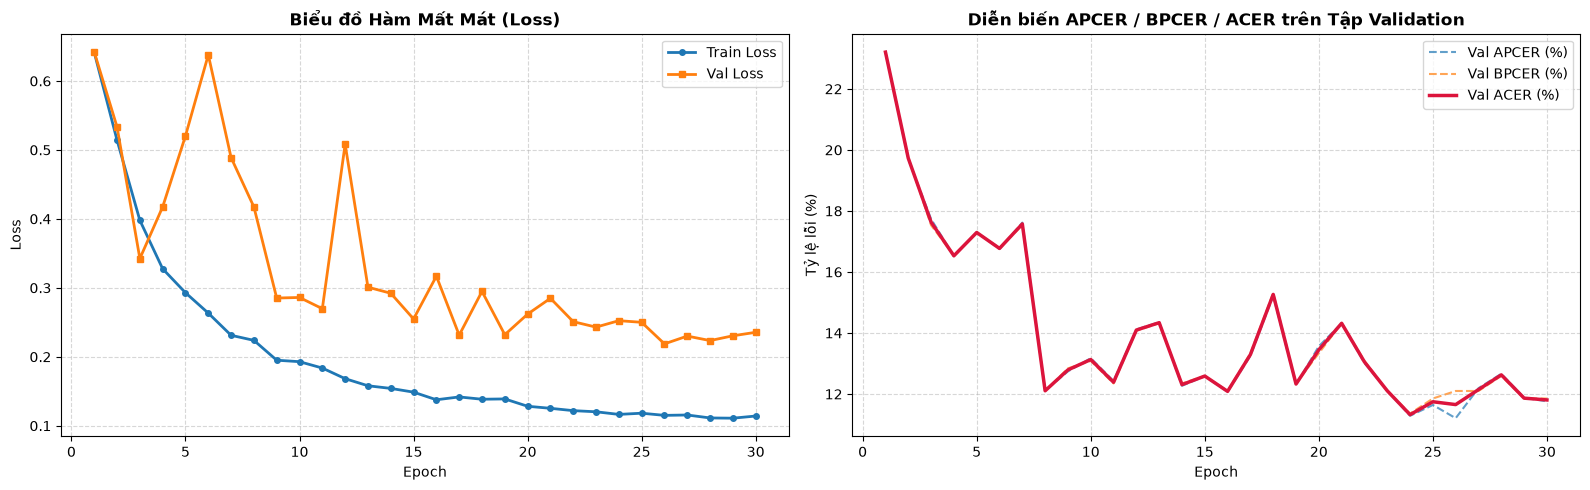

[*] Thu thập kết quả dự đoán trên tập Val...


[*] Thu thập kết quả dự đoán trên tập Test...


✅ Đánh giá xong! F1-Score trên tập Test: 0.9195 (Threshold = 0.6901)

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        real       0.21      0.90      0.34       314
       spoof       1.00      0.85      0.92      7266

    accuracy                           0.86      7580
   macro avg       0.60      0.88      0.63      7580
weighted avg       0.96      0.86      0.90      7580

-----------------------------



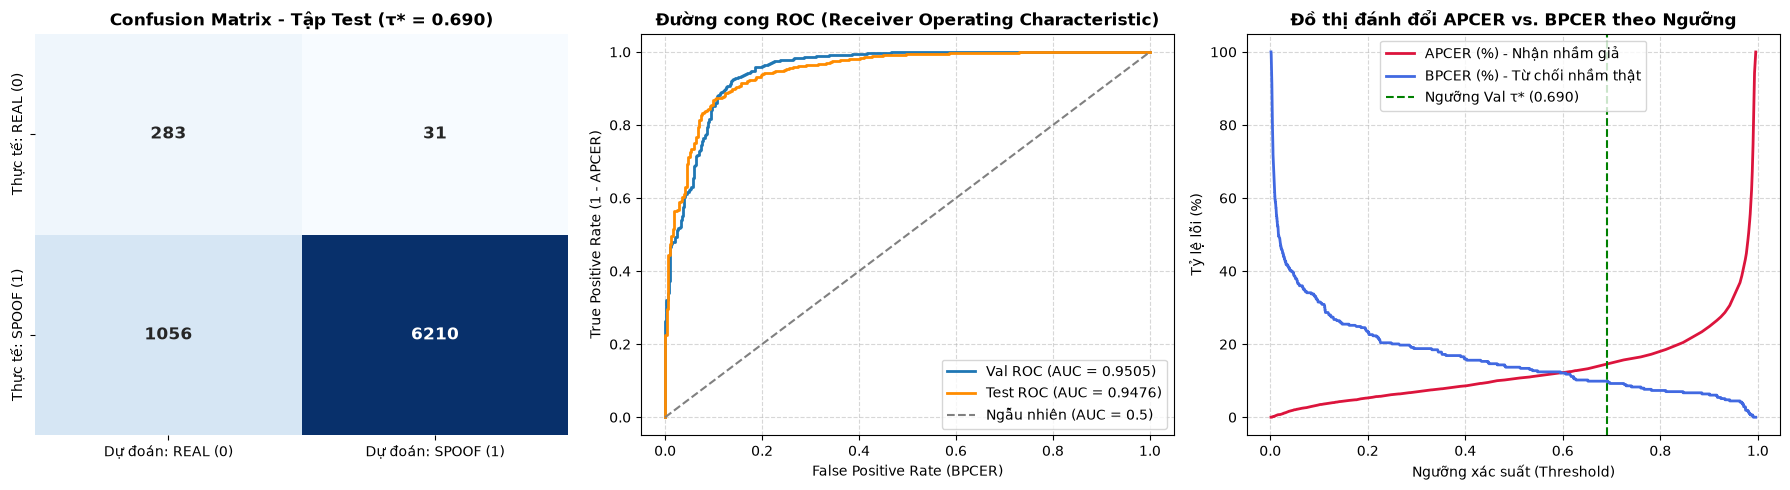

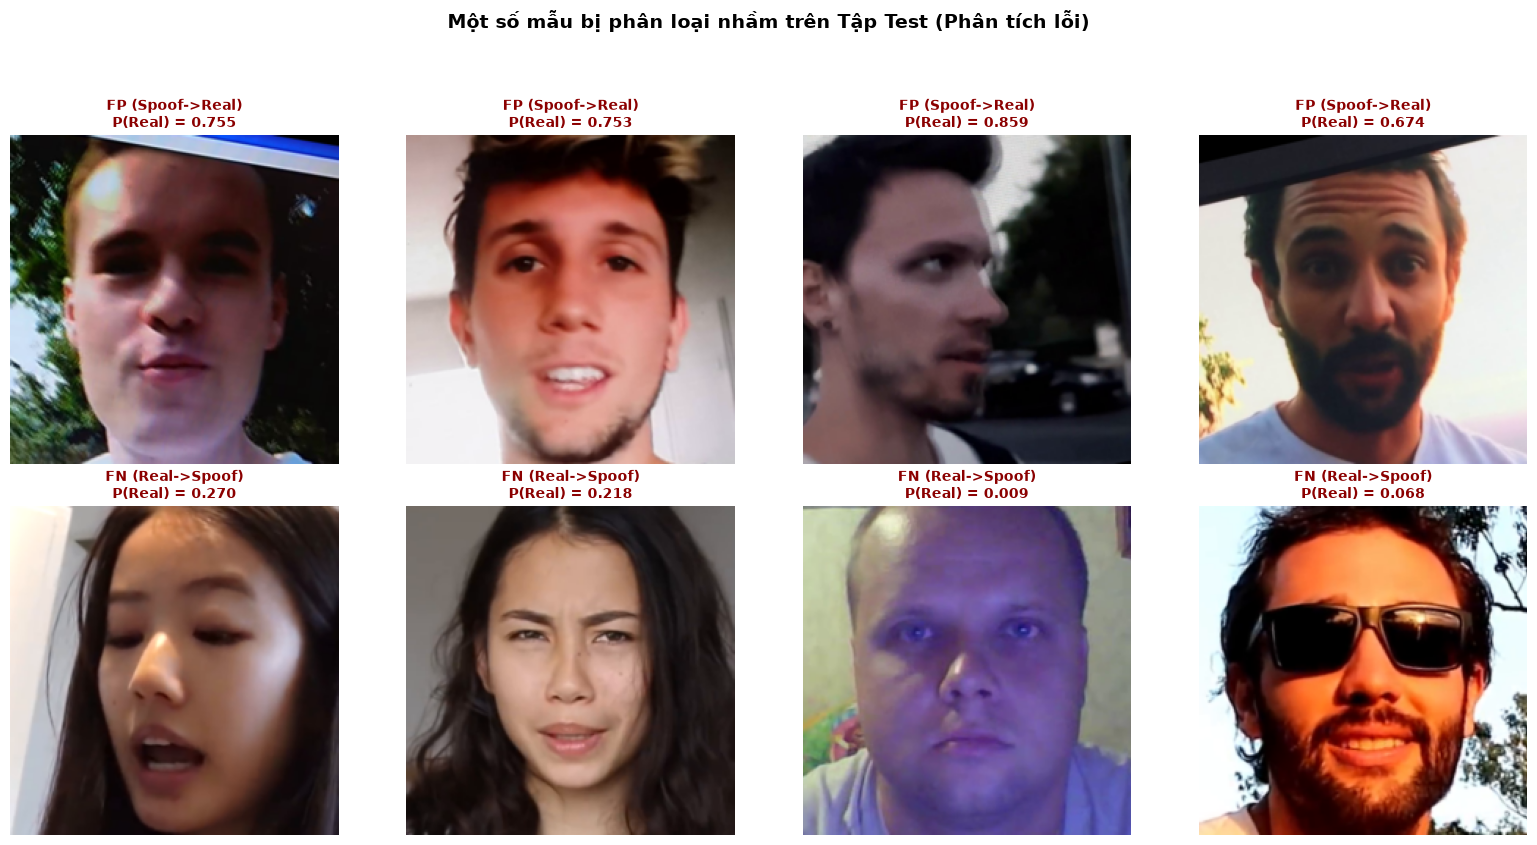

In [7]:
plot_training_history(history, save_dir=OUT_DIR)

test_probs, test_labels, test_preds = evaluate_test_set(
    best_model, val_loader, test_loader, device, class_names, 
    threshold=best_threshold, save_dir=OUT_DIR
)

plot_misclassified_samples(
    test_loader.dataset, test_probs, test_preds, test_labels, class_names, 
    num_samples=4, save_dir=OUT_DIR
)

In [8]:
OUT_MODEL_DIR = "../output/models/custome"
os.makedirs(OUT_MODEL_DIR, exist_ok=True)
onnx_path = os.path.join(OUT_MODEL_DIR, "custome_model.onnx")

best_model.eval()
dummy_input = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE, device=device)

torch.onnx.export(
    best_model, 
    dummy_input, 
    onnx_path, 
    input_names=['input'], 
    output_names=['output']
)
print(f"Đã xuất mô hình ONNX thành công tại: {onnx_path}")

[torch.onnx] Obtain model graph for `CustomeModelCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CustomeModelCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Đã xuất mô hình ONNX thành công tại: ../output/models/custome/custome_model.onnx
